In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


In [2]:
import matplotlib

# Set matplotlib to save text as text (not paths)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts
matplotlib.rcParams['ps.fonttype'] = 42   # For postscript output

# Set your figure parameters
sc.settings.set_figure_params(
    dpi=100,
    frameon=False,
    figsize=(3, 3),
    vector_friendly=True,  # This is important!
    fontsize=8
)

In [3]:
# Load dataset
os.chdir("/storage2/liuxiaodongLab/fanxueying/liu-lab_projects/XueyingFan/Hypoblast/code/20260312_hypo_final_annotation")
adata = sc.read('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20260310_hypoblast_dataset/output_02/h5ad_results/final_complete.h5ad')
adata

AnnData object with n_obs × n_vars = 2550159 × 37961
    obs: 'orig.ident', 'lineage_pred', 'leiden_scpoli_1', 'condition', 'cell_name_in_hg38_mm10', 'batch', 'seq', 'time', 'group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden', 'lineage_uncert'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg_genes'
    obsm: 'X_umap', 'scPoli'

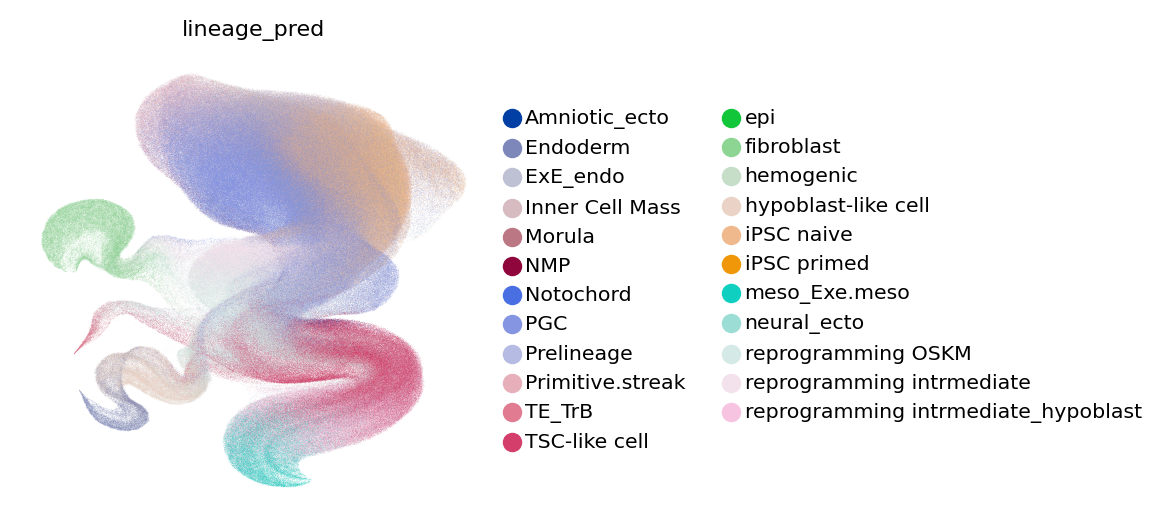

In [4]:
sc.pl.umap(
    adata,
    color="lineage_pred",
  #  save="hypo100_celltype_umap.pdf"  # Saves as 'figures/umap_celltype_umap.pdf'
)

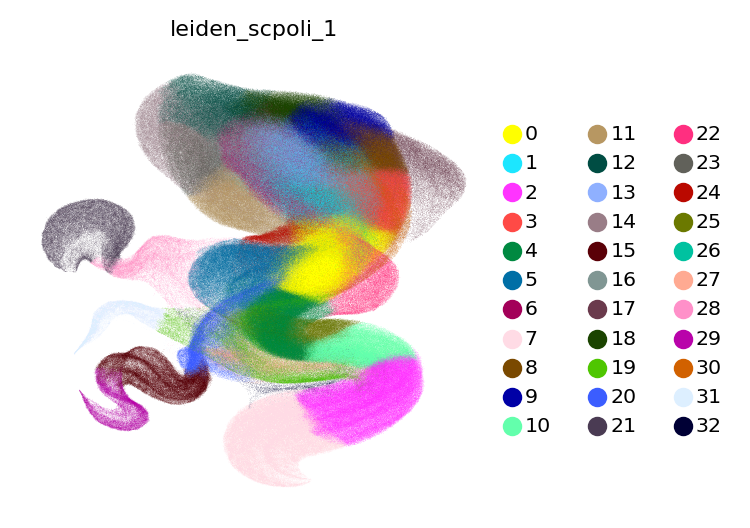

In [5]:
sc.pl.umap(
    adata,
    color="leiden_scpoli_1",
  #  save="hypo100_leiden_scpoli_umap.pdf" 
)

原始数据shape: (2550159, 37961)
cluster列: 'leiden_scpoli_1'
每个cluster的细胞数:
0     256959
1     174269
2     158854
3     141934
4     134693
5     114745
6     111106
7     106928
8     101493
9     100302
10     84252
11     76248
12     72509
13     67968
14     65837
15     65142
16     64984
17     64364
18     62568
19     59560
20     55333
21     53787
22     53348
23     50577
24     42517
25     41648
26     32727
27     31901
28     31655
29     25177
30     23778
31     14618
32      8378
Name: leiden_scpoli_1, dtype: int64

开始随机采样...
Cluster 14: 65837 细胞 -> 采样 500 细胞
Cluster 7: 106928 细胞 -> 采样 500 细胞
Cluster 23: 50577 细胞 -> 采样 500 细胞
Cluster 3: 141934 细胞 -> 采样 500 细胞
Cluster 15: 65142 细胞 -> 采样 500 细胞
Cluster 11: 76248 细胞 -> 采样 500 细胞
Cluster 17: 64364 细胞 -> 采样 500 细胞
Cluster 9: 100302 细胞 -> 采样 500 细胞
Cluster 24: 42517 细胞 -> 采样 500 细胞
Cluster 16: 64984 细胞 -> 采样 500 细胞
Cluster 12: 72509 细胞 -> 采样 500 细胞
Cluster 32: 8378 细胞 -> 采样 500 细胞
Cluster 26: 32727 细胞 -> 采样 500 细胞
Cluster 29: 

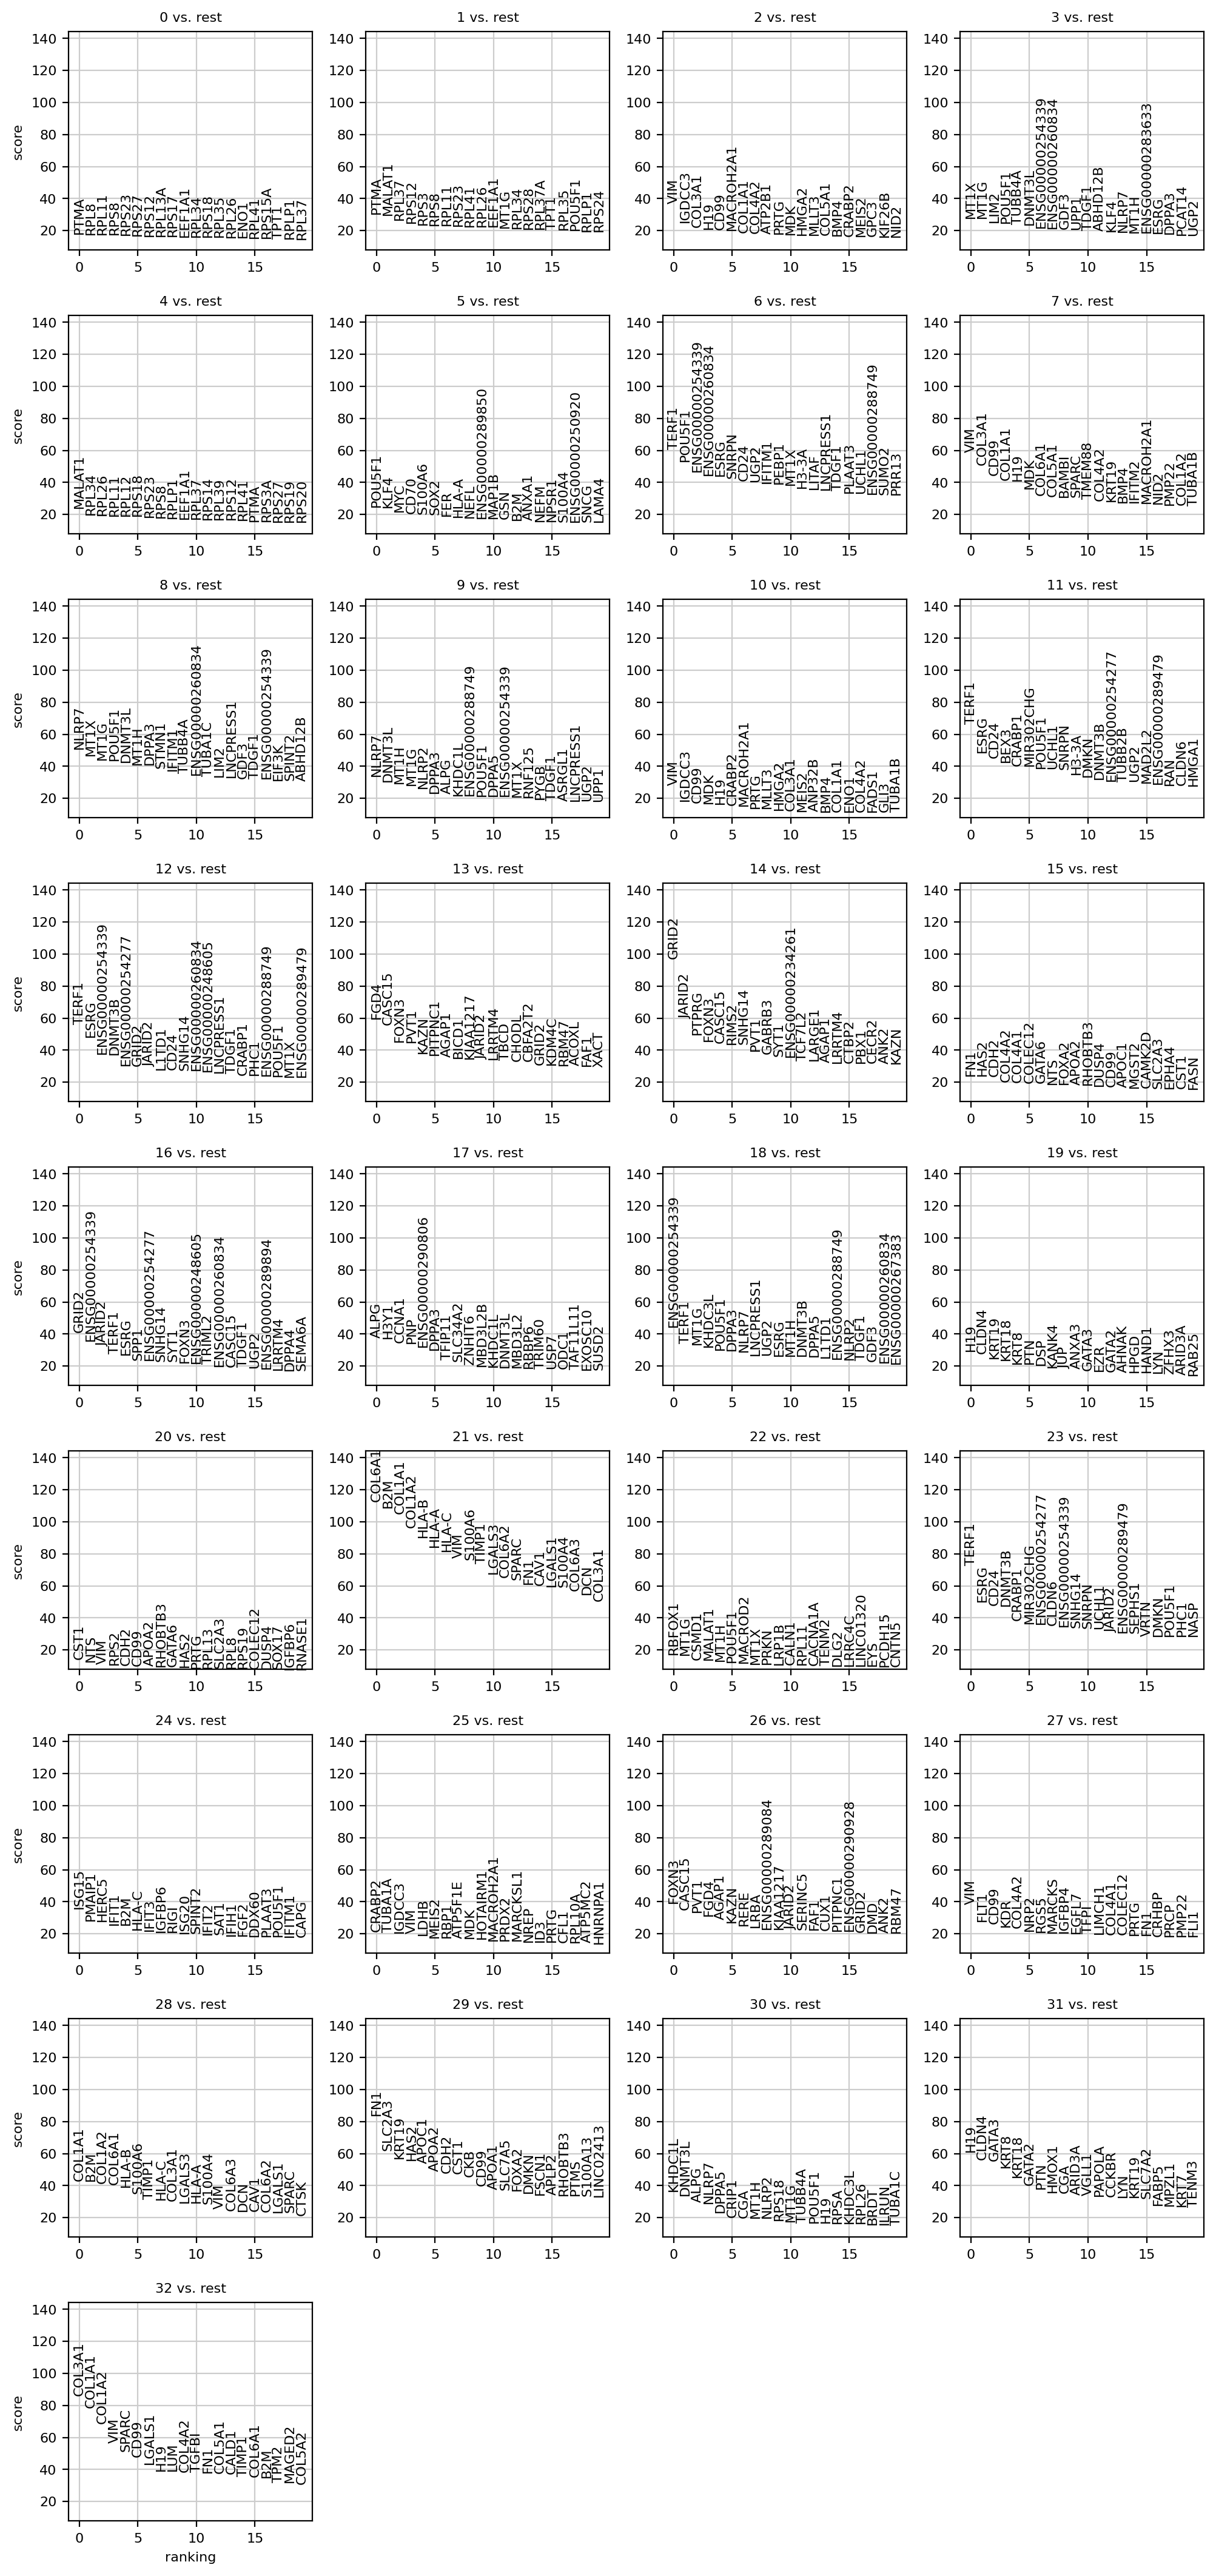

In [6]:
from sklearn.utils import resample

print(f"原始数据shape: {adata.shape}")
print(f"cluster列: 'leiden_scpoli_1'")
print(f"每个cluster的细胞数:")
print(adata.obs['leiden_scpoli_1'].value_counts())

# 从每个cluster随机采样500个细胞
print("\n开始随机采样...")
sampled_cells = []

# 获取所有唯一的cluster
clusters = adata.obs['leiden_scpoli_1'].unique()

for cluster in clusters:
    # 获取当前cluster的所有细胞
    cluster_cells = adata.obs[adata.obs['leiden_scpoli_1'] == cluster].index
    
    # 如果该cluster细胞数少于500，则全部保留
    n_samples = min(500, len(cluster_cells))
    
    # 随机采样
    sampled = np.random.choice(cluster_cells, size=n_samples, replace=False)
    sampled_cells.extend(sampled)
    
    print(f"Cluster {cluster}: {len(cluster_cells)} 细胞 -> 采样 {n_samples} 细胞")

# 创建采样子集
adata_subset = adata[sampled_cells].copy()
print(f"\n采样后数据shape: {adata_subset.shape}")

# 可选：保存采样的数据
# adata_subset.write('adata_sampled_500_per_cluster.h5ad')
# print("采样数据已保存为 'adata_sampled_500_per_cluster.h5ad'")

# 计算每个cluster的marker基因
print("\n开始计算marker基因...")

# 确保数据已标准化
if 'log1p' not in adata_subset.uns.keys():
    print("对数据进行标准化...")
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)

# 计算marker基因
sc.tl.rank_genes_groups(
    adata_subset, 
    groupby='leiden_scpoli_1', 
    method='t-test',  # 可以使用 't-test', 'wilcoxon', 'logreg' 等
    key_added='rank_genes_groups',
    n_genes=50,  # 每个cluster返回top 50个marker基因
    use_raw=False
)

# 提取marker基因结果
marker_results = []
for cluster in clusters:
    # 获取该cluster的marker基因
    markers = sc.get.rank_genes_groups_df(adata_subset, group=str(cluster))
    markers['cluster'] = cluster
    marker_results.append(markers)

# 合并所有marker结果
marker_df = pd.concat(marker_results, ignore_index=True)

# 保存marker基因结果
marker_df.to_csv('marker_genes_per_cluster.csv', index=False)
print("Marker基因结果已保存为 'marker_genes_per_cluster.csv'")

# 打印每个cluster的top marker基因
print("\n每个cluster的top 5 marker基因:")
for cluster in clusters:
    markers = sc.get.rank_genes_groups_df(adata_subset, group=str(cluster))
    print(f"\nCluster {cluster}:")
    print(markers.head(5)[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string(index=False))

# 可选：可视化marker基因
sc.pl.rank_genes_groups(adata_subset, key='rank_genes_groups', show=True)

In [7]:
#rename
# add a new column
adata.obs['celltype'] = adata.obs['leiden_scpoli_1'].cat.add_categories(['Fibroblast', 'iPSC primed', 'iPSC_naive', '8 cell-like cell',
                                                                         'Hypoblast-like cell',
                                                                         'TSC-like cell','Amnion-like cell',
                                                                         'Meso/ExEM-like cell','HEP-like cell',
                                                                          'Reprogramming intermediate',
                                                                                  
])

adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['21' ])] = 'Fibroblast'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['17' ])] = '8 cell-like cell'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['11', '12','14', '23', '24'])] = 'iPSC primed'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['0','1','3', '6','8','9', '13','16','18', '26','30' ])] = 'iPSC_naive'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['2','7', '10', ])] = 'Meso/ExEM-like cell'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['19' ])] = 'Amnion-like cell'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['15','29' ])] = 'Hypoblast-like cell'
# adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['29' ])] = 'YS-like cell'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['27' ])] = 'HEP-like cell'
adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['31' ])] = 'TSC-like cell'



adata.obs['celltype'][np.in1d(adata.obs['celltype'], ['4','5','20', '22', '25', '28','32'])] = 'Reprogramming intermediate'










adata.obs['celltype'] = adata.obs['celltype'].cat.remove_unused_categories()

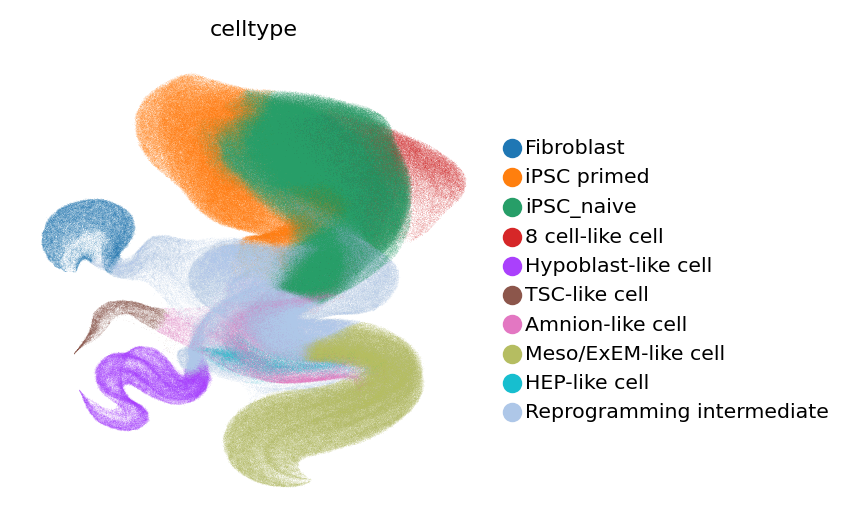

In [8]:
sc.pl.umap(
    adata,
    color="celltype",
  #  save="hypo100_leiden_scpoli_umap.pdf" 
)

In [9]:
# 提取cluster 19的细胞
print("\n提取cluster 19...")
cluster_19_mask = adata.obs['leiden_scpoli_1'] == '19'  # 注意：如果是数值型，可能需要用19而不是'19'
adata_cluster19 = adata[cluster_19_mask].copy()

print(f"Cluster 19细胞数量: {adata_cluster19.n_obs}")
print(f"基因数量: {adata_cluster19.n_vars}")



提取cluster 19...
Cluster 19细胞数量: 59560
基因数量: 37961


In [10]:
sc.pp.neighbors(adata_cluster19, use_rep="scPoli",random_state=42)
sc.tl.umap(adata_cluster19,random_state=42)
sc.tl.leiden(adata_cluster19, resolution=0.2, key_added="leiden_sub")

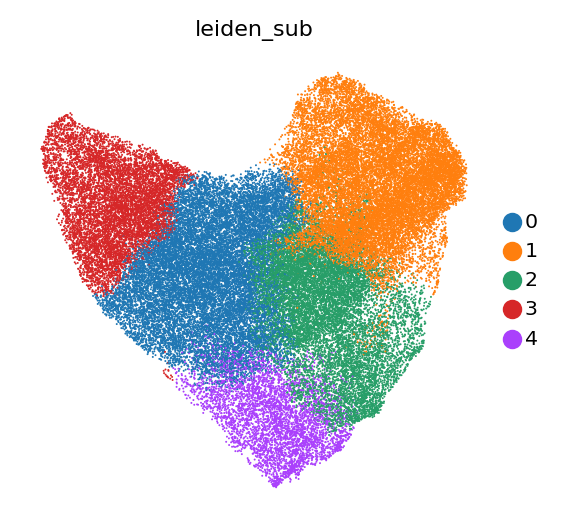

In [11]:
sc.pl.umap(adata_cluster19, color=['leiden_sub'])

In [12]:
marker_dict_select = {
    'TSC': ['GATA3', 'MSX2', 'TFAP2C', 'CDX2', 'TFAP2A'],
    'AMNION': ['ISL1', 'GABRP', 'TFAP2A', 'VTCN1'],
   
}

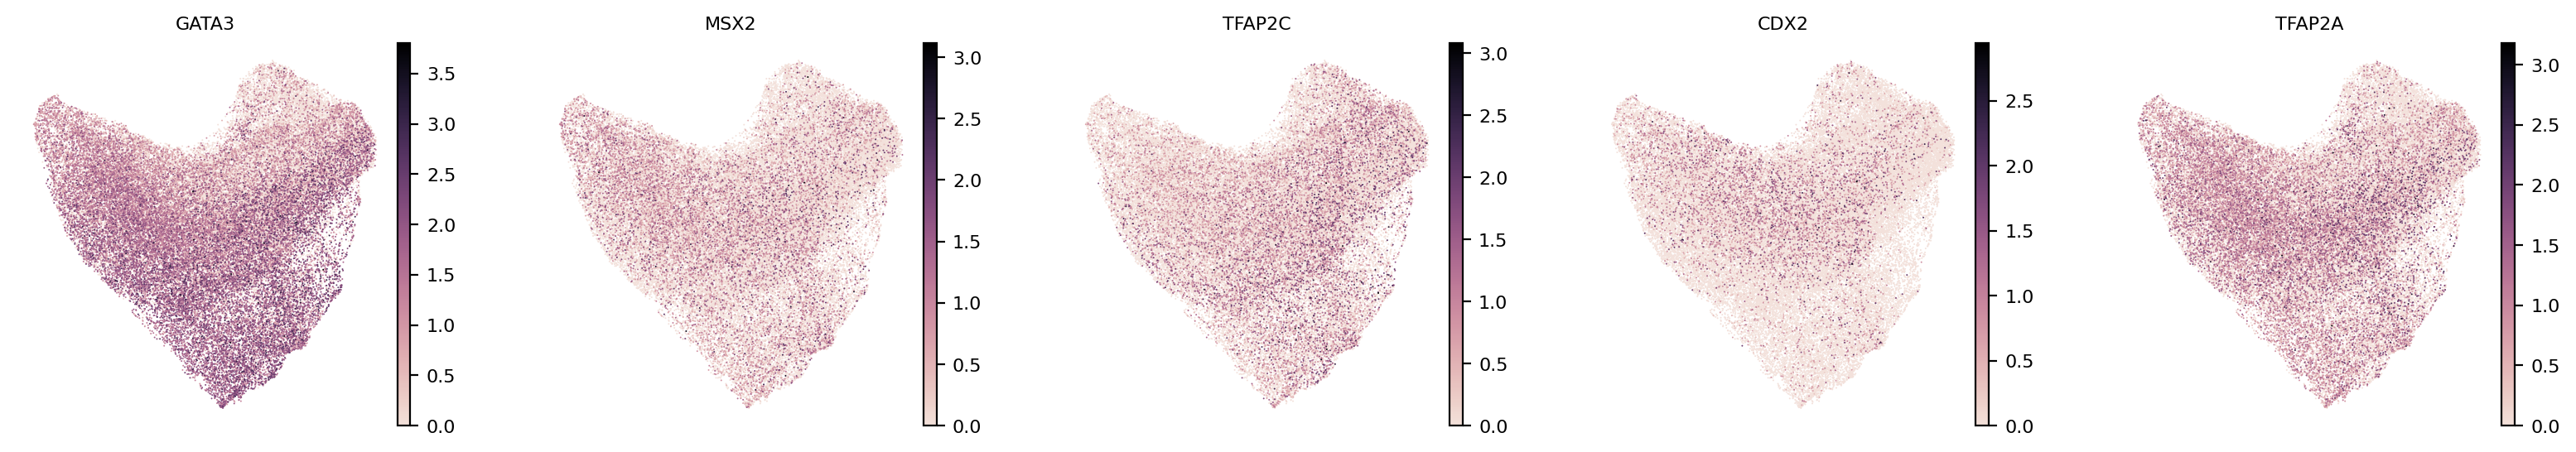

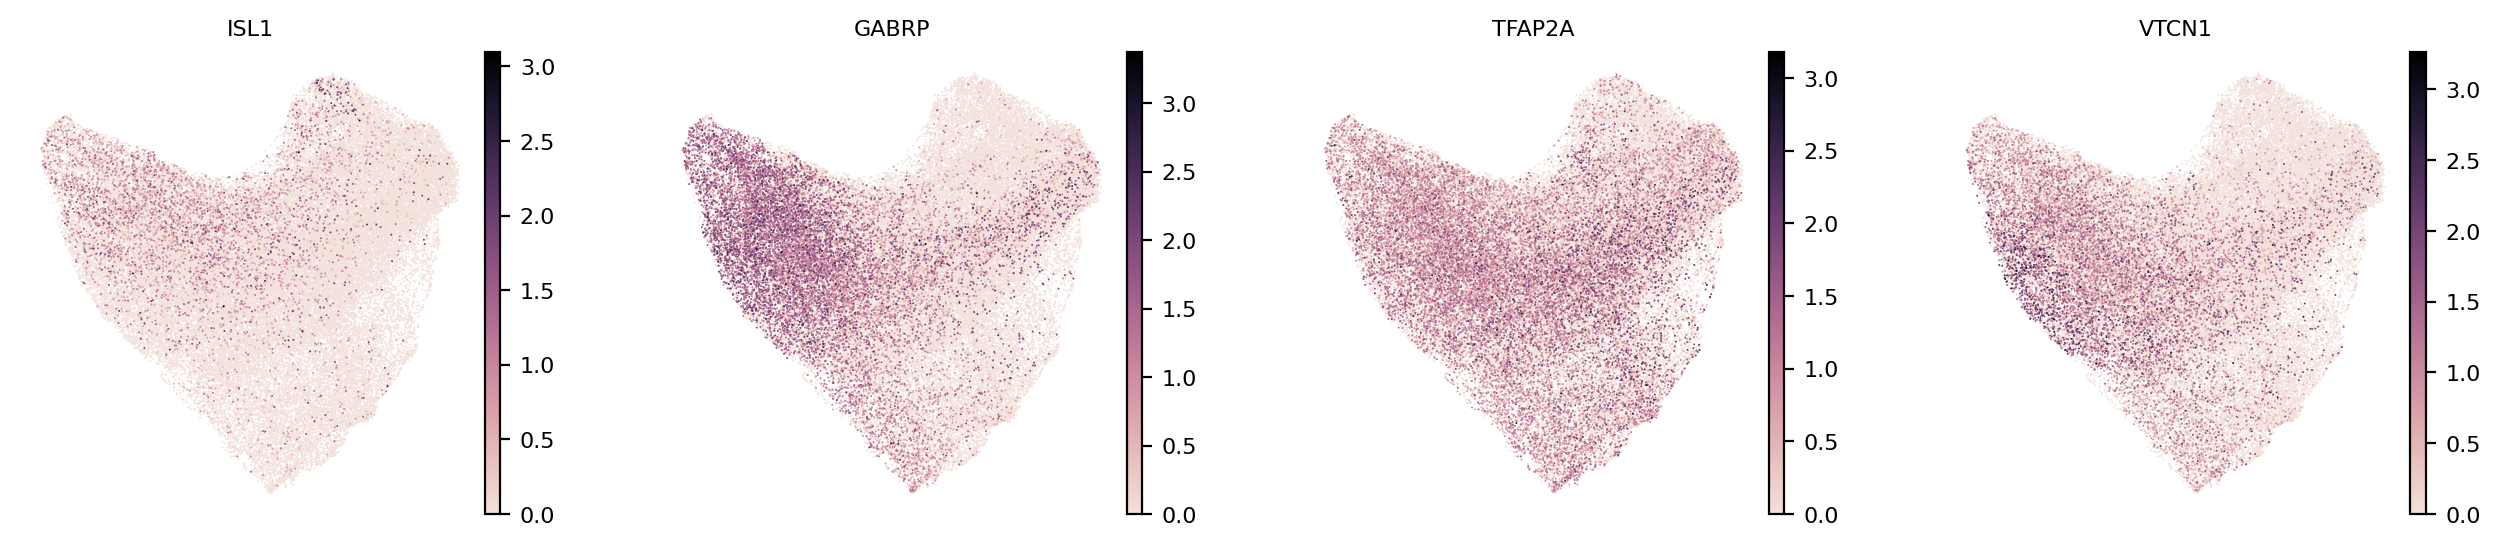

In [13]:
# 为每个组创建单独的图形
for cell_type, genes in marker_dict_select.items():
    existing_genes = [gene for gene in genes if gene in adata.var_names]
    if existing_genes:  # 只绘制存在的基因
        sc.pl.umap(adata_cluster19, color=existing_genes, ncols=len(existing_genes),
                  cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

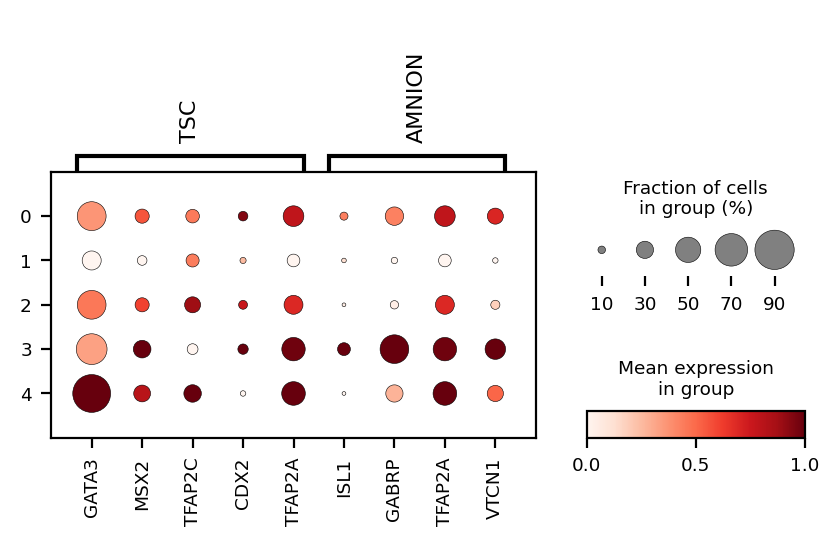

In [14]:
# Flatten your marker_dict_select into a list
all_markers = [gene for group in marker_dict_select.values() for gene in group]

# Find which ones exist in your dataset
existing_markers = [g for g in all_markers if g in adata_cluster19.var_names]

# Optional: Report missing genes
missing = set(all_markers) - set(existing_markers)
if missing:
    print(f"⚠️ Missing {len(missing)} genes: {sorted(missing)}")

# Rebuild marker_dict_select dict with only existing genes
filtered_marker_genes = {}
for group, genes in marker_dict_select.items():
    filtered = [g for g in genes if g in adata_cluster19.var_names]
    if filtered:  # Only keep groups with at least one gene
        filtered_marker_genes[group] = filtered

# Now plot
sc.pl.dotplot(
    adata_cluster19,
    filtered_marker_genes,
    groupby="leiden_sub",
    standard_scale="var",
   # save="hypo100_marker_dotplot.pdf"  # Add this line
)

In [15]:
#rename
# add a new column
adata_cluster19.obs['celltype'] = adata_cluster19.obs['leiden_sub'].cat.add_categories([ 'TSC-like cell','Amnion-like cell',
                                                               
                                                                                       
])

adata_cluster19.obs['celltype'][np.in1d(adata_cluster19.obs['celltype'], ['0','3' ])] = 'Amnion-like cell'
adata_cluster19.obs['celltype'][np.in1d(adata_cluster19.obs['celltype'], ['1','2', '4' ])] = 'TSC-like cell'

adata_cluster19.obs['celltype'] = adata_cluster19.obs['celltype'].cat.remove_unused_categories()

In [16]:
# 将celltype列转换为字符串类型，避免分类变量的问题
adata.obs['celltype'] = adata.obs['celltype'].astype(str)

# 获取cluster 19的细胞
cluster19_mask = adata.obs_names.isin(adata_cluster19.obs_names)

# 更新celltype
adata.obs.loc[cluster19_mask, 'celltype'] = adata_cluster19.obs['celltype'].values

# 如果需要，可以再转回分类变量
adata.obs['celltype'] = adata.obs['celltype'].astype('category')

print("更新完成！")
print(adata.obs['celltype'].value_counts())

更新完成！
iPSC_naive                    1138088
Reprogramming intermediate     439800
Meso/ExEM-like cell            350034
iPSC primed                    307688
Hypoblast-like cell             90319
8 cell-like cell                64364
Fibroblast                      53787
TSC-like cell                   48204
HEP-like cell                   31901
Amnion-like cell                25974
Name: celltype, dtype: int64


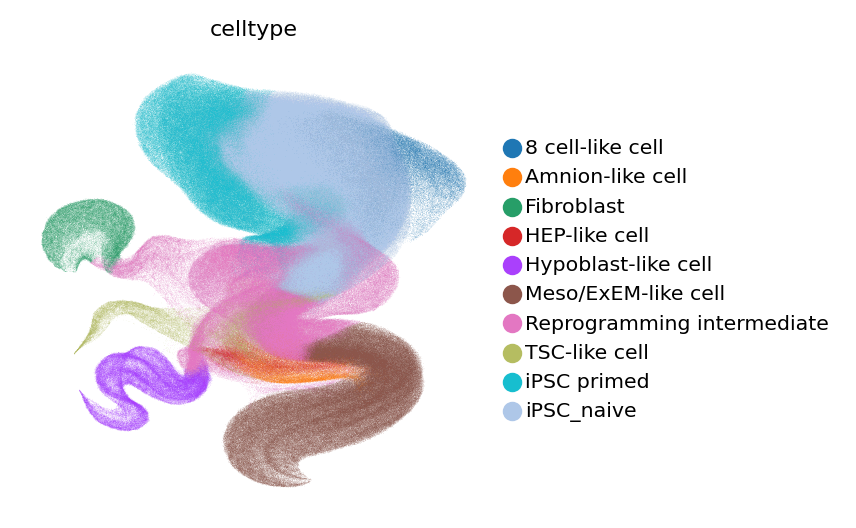

In [17]:
sc.pl.umap(
    adata,
    color="celltype",
  #  save="hypo100_leiden_scpoli_umap.pdf" 
)

In [23]:
# 定义你想要的celltype顺序
celltype_order = [
    'Fibroblast', 
    'iPSC primed', 
    'iPSC_naive', 
    '8 cell-like cell',
    'Hypoblast-like cell',
    'TSC-like cell',
    'Amnion-like cell',
    'Meso/ExEM-like cell',
    'HEP-like cell',
    'Reprogramming intermediate'
]

# 检查哪些celltype存在于数据中
existing_celltypes = [ct for ct in celltype_order if ct in adata.obs['celltype'].unique()]
missing_celltypes = set(celltype_order) - set(existing_celltypes)

if missing_celltypes:
    print(f"⚠️ 以下celltype在数据中不存在: {sorted(missing_celltypes)}")
    print(f"数据中现有的celltype: {sorted(adata.obs['celltype'].unique())}")

# 使用categories重新排序（如果celltype是分类变量）
if isinstance(adata.obs['celltype'].dtype, pd.CategoricalDtype):
    # 只重新排序存在的类别
    adata.obs['celltype'] = adata.obs['celltype'].cat.reorder_categories(
        existing_celltypes, 
        ordered=True
    )
else:
    # 如果不是分类变量，转换为分类变量并排序
    adata.obs['celltype'] = pd.Categorical(
        adata.obs['celltype'], 
        categories=existing_celltypes, 
        ordered=True
    )

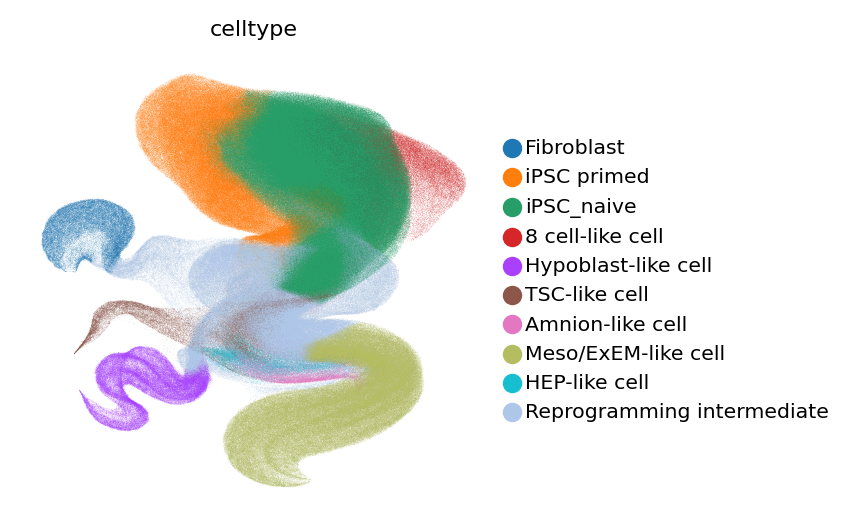

In [29]:
sc.pl.umap(
    adata,
    color="celltype",
    save="hypo100_leiden_scpoli_umap.pdf" 
)

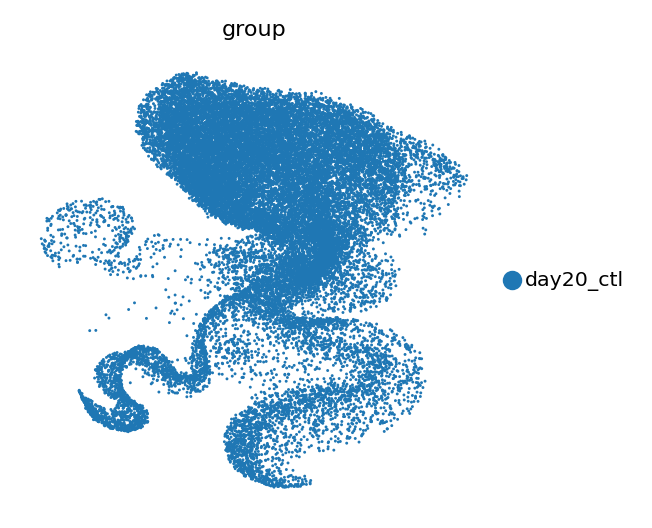

In [18]:
clusters_to_show = ["day20_ctl"]

adata_subset = adata[adata.obs["group"].isin(clusters_to_show)].copy()

sc.pl.umap(adata_subset, color="group")

In [110]:
# marker_dict_select = {
#     'Fibroblast': ['COL1A1', 'FN1', 'MMP2', 'ZEB1', 'VIM'],
#     'iPSC naive': ['DPPA5', 'DPPA3', 'DPPA2', 'DNMT3L', 'KLF17', 'TFCP2L1'],
#     'iPSC primed': ['NANOG', 'LIN28A', 'EPCAM', 'POU5F1', 'CD24','SOX11', 'ESRG' ,'EPCAM'],
#     'TSC': ['GATA3', 'MSX2', 'TFAP2C', 'CDX2', 'TFAP2A'],
#     'Hypoblast': ['SOX17', 'GATA4', 'GATA6', 'PDGFRA'],
#     'embryonic mesoderm1':['SP5','TBXT','HOXA1','CDX1','CDX2','MIXL1'],
#     'embryonic mesoderm2':['MESP1','HAND1','TWIST1','TWIST2','THY1'],
#     'embryonic mesoderm3':['FOXF1','ACTA2','RGS5','BMP4','EOMES'],
#     'PS': ['TBXT', 'MESP1', 'EOMES', 'MIXL1'],
#     'PGC': ['NANOS3', 'SOX17', 'TFAP2C', 'NANOG', 'PRDM1'],
#     'HEP': ['CD34', 'ERG', 'MEF2C', 'PECAM1'],
#     'AMNION': ['ISL1', 'GABRP', 'TFAP2A', 'VTCN1'],
#     '8CLC': ['ZSCAN4', 'TPRX1', 'DUXA', 'ZSCAN5B', 'ZNF280A'],
#     'neural': ['SOX1', 'PAX6', 'SOX2', 'HES1', 'TUBB3'],
#     'YS': ['APOA1', 'APOB', 'RSPO3'],
    
# }

In [9]:
marker_dict_select = {
    'Fibroblast': ['COL1A1', 'FN1', 'MMP2',  'VIM'],
    'iPSC naive': ['DPPA5',  'DNMT3L', 'DPPA2', 'TFCP2L1'],
    'iPSC primed': ['POU5F1', 'NANOG',  'EPCAM',  'CD24','ESRG' ],
    '8CLC': ['ZSCAN4', 'TPRX1', 'ZNF280A'],
     'Hypoblast': ['SOX17', 'GATA4', 'GATA6', 'PDGFRA', 'FOXA2'],
    'TSC': ['GATA2', 'GATA3', 'TFAP2C', 'KRT7'],
    'AMNION': ['GABRP', 'TFAP2A', 'VTCN1'],
    'Meso/ExEM':['HAND2','ACTA2','BMP4', 'NID2'],
    'HEP': ['CD34', 'MEF2C', 'PECAM1'],
    
    
   # 'neural': ['SOX1', 'PAX6', 'SOX2', 'HES1', 'TUBB3'],
    # 'YS': ['APOA1', 'APOB', 'RSPO3'],
    
}

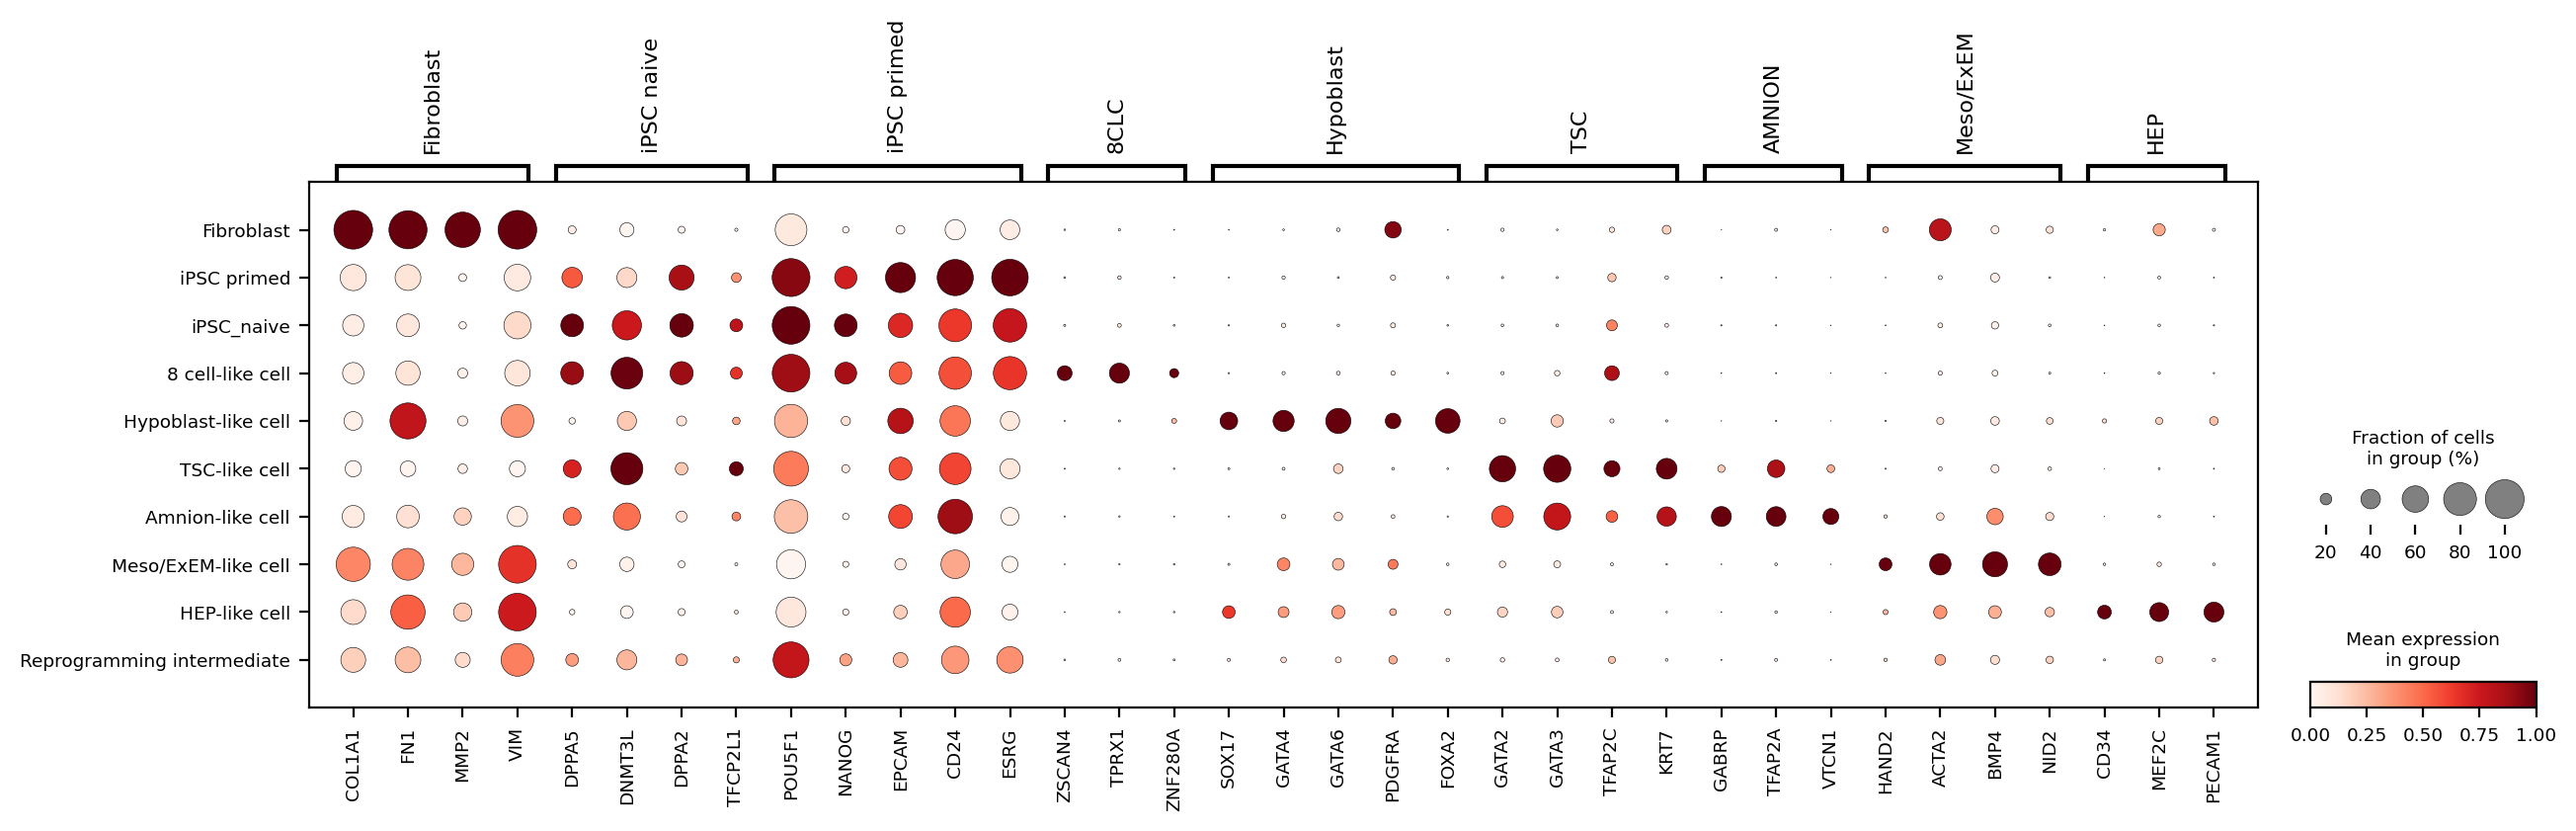

In [10]:
# Flatten your marker_dict_select into a list
all_markers = [gene for group in marker_dict_select.values() for gene in group]

# Find which ones exist in your dataset
existing_markers = [g for g in all_markers if g in adata.var_names]

# Optional: Report missing genes
missing = set(all_markers) - set(existing_markers)
if missing:
    print(f"⚠️ Missing {len(missing)} genes: {sorted(missing)}")

# Rebuild marker_dict_select dict with only existing genes
filtered_marker_genes = {}
for group, genes in marker_dict_select.items():
    filtered = [g for g in genes if g in adata.var_names]
    if filtered:  # Only keep groups with at least one gene
        filtered_marker_genes[group] = filtered

# Now plot
sc.pl.dotplot(
    adata,
    filtered_marker_genes,
    groupby="celltype",
    standard_scale="var",
    save="hypo100_marker_dotplot.pdf"  # Add this line
)

In [30]:
adata.write_h5ad("hypo_final_20260313.h5ad")

In [3]:
# Load dataset
os.chdir("/storage2/liuxiaodongLab/fanxueying/liu-lab_projects/XueyingFan/Hypoblast/code/20260312_hypo_final_annotation")
adata = sc.read('hypo_final_20260313.h5ad', backed='r')
adata

AnnData object with n_obs × n_vars = 2550159 × 37961 backed at 'hypo_final_20260313.h5ad'
    obs: 'orig.ident', 'lineage_pred', 'leiden_scpoli_1', 'condition', 'cell_name_in_hg38_mm10', 'batch', 'seq', 'time', 'group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden', 'lineage_uncert', 'celltype'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltype_colors', 'hvg_genes', 'leiden_scpoli_1_colors', 'lineage_pred_colors'
    obsm: 'X_umap', 'scPoli'

In [4]:
print(set(adata.obs['group']))

{'EPZ_FGF4', 'LDN_PDG_LIF', 'BMP4_CHIR', 'A83_FGF4_LIF', 'IGF1_CHIR', 'BMP4_XAV', 'A83_BMP4_XAV_PDG_LIF', 'A83_CHIR_LIF', 'PD0_CHIR_LIF_Go6983', 'Act_FGF4_PDG', 'BMP4_PDG', 'Act_CHIR_LIF', 'PD0_XAV_DZN_VPA_Act_LIF_VitC', 'EPZ_CHIR', 'LDN_XAV_FGF4', 'Act_LDN_PDG', 'A83_LDN_XAV', 'LDN_CHIR_PDG', 'BMP4', 'Act_BMP4_XAV_FGF4_PDG_LIF', 'BMP4_XAV_LIF', 'CHIR_VPA_EPZ_RA_VitC', 'FGF2_Act_XAV_SP_VitC', 'BMP4_XAV_FGF4', 'FGF4', 'Act_BMP4_LIF', 'A83_PDG', 'Act_IGF1_FGF2', 'FGF2_Act_VitC_Forskolin', 'Act_XAV', 'LDN', 'XAV_PDG', 'IL6', 'Act_BMP4_XAV', 'VitC', 'Go6983_Forskolin', 'A83_LDN_FGF4', 'DZNeP_EPZ', 'VPA', 'Act_LDN', 'Act_LDN_CHIR', 'PD0_XAV_Go6983_CGP_LIF', 'Act_BMP4_FGF4', 'CHIR_FGF4', 'A83_XAV_LIF', 'Act_BMP4_PDG', 'LDN_PDG', 'A83_BMP4', 'A83_CHIR_PDG', 'RA', 'A83_PDG_LIF', 'A83_BMP4_CHIR_FGF4_LIF', 'BMP4_FGF4', 'Act_PDG', 'BMP4_CHIR_FGF4', 'DZNeP_LDN', 'SP_FGF4', 'XAV', 'Go6983_DZNeP', 'XAV_FGF4_LIF', 'Act_CHIR_PDG', 'BMP4_CHIR_LIF', 'VitC_PDG', 'PD0_A83_BMP4_VPA', 'A83', 'day20_ctl', 'P

In [5]:
import anndata as ad
import pandas as pd

# Test conditions from file (normalized: A83-01 -> A83, LIF/IL6 -> LIF, spaces removed, slashes handled)
test_conditions_raw = [
    "A83-01_BMP4_LIF/IL6_PDGFAA",
    "Activin-A_BMP4_CHIR99021_FGF4_LIF/IL6_PDGFAA",
    "Activin-A_BMP4_FGF4_LIF/IL6_PDGFAA_XAV939",
    "Activin-A_CHIR99021_FGF4_LDN193_LIF/IL6_PDGFAA",
    "Activin-A_FGF4_LDN193_LIF/IL6_PDGFAA_XAV939",
    "A83-01_CHIR99021_FGF4_LDN193_LIF/IL6_PDGFAA",
    "A83-01_FGF4_LDN193_LIF/IL6_PDGFAA_XAV939",
    "BMP4_FGF4_PDGFAA_XAV939",
    "A83-01_CHIR99021_FGF4_LIF/IL6",
    "Activin-A_CHIR99021_LDN193_PDGFAA",
    "A83-01_BMP4_LIF/IL6_PDGFAA_XAV939",
    "A83-01_BMP4_CHIR99021_FGF4_LIF/IL6",
    "Activin-A_CHIR99021_FGF4_LDN193_PDGFAA",
    "Gö6983_LIF/IL6_PD0325901_XAV939",
    "CGP77675_Gö6983_LIF/IL6_PD0325901_XAV939",
    "Activin-A_DZN_LIF/IL6_PD0325901_VPA_Vitamin C_XAV939",
    "DZN_LIF/IL6_PD0325901_VPA_Vitamin C_XAV939",
    "CHIR99021_EPZ004777_Retinoic Acid (RA)_VPA_Vitamin C",
    "A83-01_BMP4_PD0325901_VPA",
    "A83-01_BMP4_CHIR99021_PD0325901_VPA",
    "Activin-A_FGF2_XAV939",
    "Activin-A_FGF2_IGF1_XAV939",
    "Activin-A_FGF2_SP600125_Vitamin C_XAV939",
    "Activin-A_FGF2_Forskolin_Vitamin C",
]

def get_components(name, is_raw_condition=False):
    """Return a frozenset of normalized components for order-independent matching."""
    
    # Abbreviation map for raw condition names -> group abbreviations
    abbrev = {
        "A83-01": "A83",
        "Activin-A": "Act",
        "LIF/IL6": "LIF",
        "LDN193": "LDN",
        "PDGFAA": "PDG",
        "CHIR99021": "CHIR",
        "Vitamin C": "VitC",
        "Retinoic Acid (RA)": "RA",
        "Gö6983": "Go6983",
        "EPZ004777": "EPZ",
        "CGP77675": "CGP",
        "XAV939": "XAV",
        "PD0325901": "PD0",
        "SP600125": "SP",
        "Forskolin": "Forskolin",
        "DZN": "DZN",          # keep as DZN (group uses both DZN and DZNeP)
        "VPA": "VPA",
        "WH-4-023": "WH4",
        "BMP4": "BMP4",
        "FGF4": "FGF4",
        "FGF2": "FGF2",
        "Y-27632": "Y27632",
        "5-Azacytidine": "5-Azacytidine",
        "IGF1": "IGF1",
    }
    
    parts = name.split("_")
    
    if is_raw_condition:
        normalized = []
        for p in parts:
            normalized.append(abbrev.get(p, p))
        return frozenset(normalized)
    else:
        # Group names: also normalize DZNeP -> DZN for matching
        return frozenset(p.replace("DZNeP", "DZN") for p in parts)

# Build test set as frozensets of components
# Build test set as frozensets of components
test_set_frozensets = set()
for c in test_conditions_raw:
    test_set_frozensets.add(get_components(c, is_raw_condition=True))

# Preview
print("Normalized test conditions (as component sets):")
for c in test_conditions_raw:
    print(f"  {sorted(get_components(c, is_raw_condition=True))}")

# Match groups — store as proper Categorical, Training first so Validation plots on top
adata.obs["set"] = pd.Categorical(
    ["Validation" if get_components(g, is_raw_condition=False) in test_set_frozensets else "Training"
     for g in adata.obs["group"]],
    categories=["Training", "Validation"]  # order matters for plotting
)

# Validation
test_groups = sorted(adata.obs[adata.obs["set"] == "Validation"]["group"].unique().tolist())
training_groups = sorted(adata.obs[adata.obs["set"] == "Training"]["group"].unique().tolist())

print(f"\n✅ 'Validation' groups ({len(test_groups)}):")
for g in test_groups:
    print(f"  {g}  ->  {sorted(get_components(g))}")

print(f"\nValue counts:\n{adata.obs['set'].value_counts()}")

Normalized test conditions (as component sets):
  ['A83', 'BMP4', 'LIF', 'PDG']
  ['Act', 'BMP4', 'CHIR', 'FGF4', 'LIF', 'PDG']
  ['Act', 'BMP4', 'FGF4', 'LIF', 'PDG', 'XAV']
  ['Act', 'CHIR', 'FGF4', 'LDN', 'LIF', 'PDG']
  ['Act', 'FGF4', 'LDN', 'LIF', 'PDG', 'XAV']
  ['A83', 'CHIR', 'FGF4', 'LDN', 'LIF', 'PDG']
  ['A83', 'FGF4', 'LDN', 'LIF', 'PDG', 'XAV']
  ['BMP4', 'FGF4', 'PDG', 'XAV']
  ['A83', 'CHIR', 'FGF4', 'LIF']
  ['Act', 'CHIR', 'LDN', 'PDG']
  ['A83', 'BMP4', 'LIF', 'PDG', 'XAV']
  ['A83', 'BMP4', 'CHIR', 'FGF4', 'LIF']
  ['Act', 'CHIR', 'FGF4', 'LDN', 'PDG']
  ['Go6983', 'LIF', 'PD0', 'XAV']
  ['CGP', 'Go6983', 'LIF', 'PD0', 'XAV']
  ['Act', 'DZN', 'LIF', 'PD0', 'VPA', 'VitC', 'XAV']
  ['DZN', 'LIF', 'PD0', 'VPA', 'VitC', 'XAV']
  ['CHIR', 'EPZ', 'RA', 'VPA', 'VitC']
  ['A83', 'BMP4', 'PD0', 'VPA']
  ['A83', 'BMP4', 'CHIR', 'PD0', 'VPA']
  ['Act', 'FGF2', 'XAV']
  ['Act', 'FGF2', 'IGF1', 'XAV']
  ['Act', 'FGF2', 'SP', 'VitC', 'XAV']
  ['Act', 'FGF2', 'Forskolin', 'VitC']


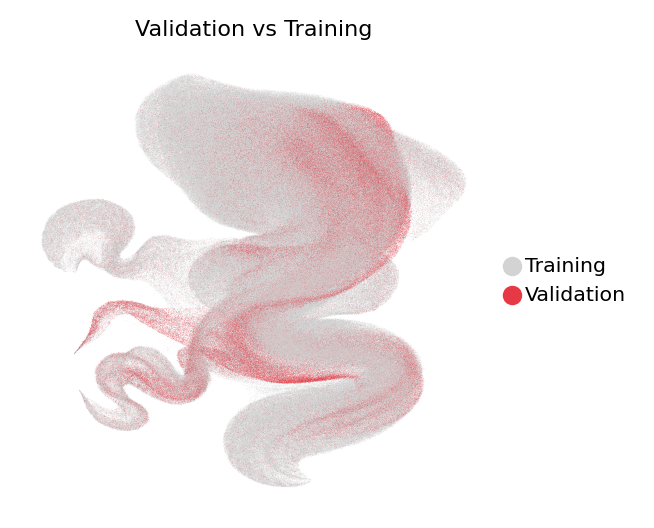

In [6]:
sc.pl.umap(
    adata,
    color="set",
    palette={"Training": "#d3d3d3", "Validation": "#e63946"},
    size=0.05,
    title="Validation vs Training",
    save="set_umap.pdf"
)

In [7]:
group_counts = adata.obs.groupby('set')['group'].nunique()
print(group_counts)

set
Training      159
Validation     24
Name: group, dtype: int64


In [10]:
# Basic export
set_group_expanded = adata.obs[['set', 'group']].drop_duplicates().sort_values(['set', 'group'])
set_group_expanded.to_csv('set_group_unique_pairs.csv', index=False)

In [13]:
import pandas as pd

# 定义缩写映射（从缩写到全名）
abbrev_to_full = {
    "A83": "A83-01",
    "Act": "Activin-A",
    "LIF": "LIF",
    "LDN": "LDN193",
    "PDG": "PDGFAA",
    "CHIR": "CHIR99021",
    "VitC": "Vitamin C",
    "RA": "Retinoic Acid (RA)",
    "Go6983": "Gö6983",
    "EPZ": "EPZ004777",
    "CGP": "CGP77675",
    "XAV": "XAV939",
    "PD0": "PD0325901",
    "SP": "SP600125",
    "Forskolin": "Forskolin",
    "DZN": "DZN",
    "DZNeP": "DZNeP",
    "VPA": "VPA",
    "WH4": "WH-4-023",
    "BMP4": "BMP4",
    "FGF4": "FGF4",
    "FGF2": "FGF2",
    "Y27632": "Y-27632",
    "5-Azacytidine": "5-Azacytidine",
    "IGF1": "IGF1",
    "IL6": "IL-6",
}

# 使用已有的 set_group_expanded
# set_group_expanded = adata.obs[['set', 'group']].drop_duplicates().sort_values(['set', 'group'])

# 创建新的列表来存储展开后的数据
expanded_rows = []

for idx, row in set_group_expanded.iterrows():
    set_value = row['set']
    group_value = row['group']
    
    if pd.isna(group_value) or not isinstance(group_value, str):
        continue
    
    # 按"_"分割小分子
    molecules = group_value.split('_')
    
    # 转换为全名
    full_names = [abbrev_to_full.get(mol, mol) for mol in molecules]
    
    # 创建一行，第一列是set，后面是每个小分子
    expanded_row = [set_value] + full_names
    expanded_rows.append(expanded_row)

# 找出最大长度（包括set列）
max_len = max(len(row) for row in expanded_rows) if expanded_rows else 0

# 创建DataFrame，填充NaN使所有行长度一致
df_expanded = pd.DataFrame(expanded_rows)
df_expanded = df_expanded.fillna('')

# 导出为CSV（不包含列名和索引）
df_expanded.to_csv('set_group_molecules_expanded.csv', index=False, header=False)

# 如果需要包含列名
# df_expanded.columns = ['set'] + [f'molecule_{i+1}' for i in range(max_len-1)]
# df_expanded.to_csv('set_group_molecules_expanded_headers.csv', index=False)

print(f"已导出到 set_group_molecules_expanded.csv")
print(f"共 {len(expanded_rows)} 行，最大分子数: {max_len-1}")

已导出到 set_group_molecules_expanded.csv
共 183 行，最大分子数: 7
